In [41]:
%pip install -U numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


3.1

In [42]:
import numpy as np

np.random.seed(42)

X = np.random.rand(100,5)
print("X.shape = ",X.shape)
print("X.dtype = ",X.dtype)
print("First 5 rows:\n", X[:5])

X.shape =  (100, 5)
X.dtype =  float64
First 5 rows:
 [[0.37454012 0.95071431 0.73199394 0.59865848 0.15601864]
 [0.15599452 0.05808361 0.86617615 0.60111501 0.70807258]
 [0.02058449 0.96990985 0.83244264 0.21233911 0.18182497]
 [0.18340451 0.30424224 0.52475643 0.43194502 0.29122914]
 [0.61185289 0.13949386 0.29214465 0.36636184 0.45606998]]


3.2

In [43]:

overall_mean =  X.mean()
overall_std = X.std()

column_mean = X.mean(axis=0)
column_std = X.std(axis=0)
column_min = X.min(axis=0)
column_max = X.max(axis=0)

print("Overall mean = ", overall_mean)
print("Overall std = ",overall_std)
print("Per-column mean = " , column_mean)
print("Per-column std = ", column_std)
print("Per-column max" , column_max)
print("Per-column min " , column_min)

Overall mean =  0.49856171223401397
Overall std =  0.2983895705094454
Per-column mean =  [0.50471071 0.52523233 0.48769797 0.52125415 0.45391341]
Per-column std =  [0.29597164 0.29840167 0.29334348 0.29175012 0.30658573]
Per-column max [0.9929648  0.99005385 0.96665482 0.97439481 0.98688694]
Per-column min  [0.00919705 0.01135364 0.00552212 0.00506158 0.01545662]


4.1

In [44]:

w = np.random.randn(5)
y = X @ w

print("w = " , w)
print("y.shape = ",y.shape)
print("y[:5]", y[:5])


w =  [ 0.34175598  1.87617084  0.95042384 -0.57690366 -0.89841467]
y.shape =  (100,)
y[:5] [2.12187057 0.00259306 2.33207136 0.62139584 0.12738448]


4.2

In [45]:
w_true = np.array([1.5 , -2.0, 0.0 , 0.7, 3.0])
noise = 0.1 * np.random.randn(X.shape[0])
y_true = X @ w_true + noise 

w_guess = w_true + 0.5 * np.random.randn(5)
y_pred = X @ w_guess

mse = np.mean((y_true - y_pred) ** 2)
mae = np.mean(np.abs(y_true - y_pred))
rmse = np.sqrt(mse)

ss_res = np.sum((y_true - y_pred) ** 2)
ss_tot = np.sum((y_true - y_true.mean()) ** 2)
r2 = 1 - ss_res / ss_tot

print("MSE:" , mse)
print("MAE:" , mae)
print("RMSE:", rmse)
print("R2:" , r2)

MSE: 0.6666980996282637
MAE: 0.7221188766249809
RMSE: 0.8165158293800945
R2: 0.6249727877273183


5.1

In [46]:

import pandas as pd

col_names = [f"x{i}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns = col_names)

df["target"] = y_true

display(df.head())
print("Shape : ", df.shape)
display(df.describe())
print ("\nMissing values:\n", df.isnull().sum())



,x0,x1,x2,x3,x4,target
0,0.374540,0.950714,0.731994,0.598658,0.156019,-0.403310
1,0.155995,0.058084,0.866176,0.601115,0.708073,2.530799
2,0.020584,0.969910,0.832443,0.212339,0.181825,-1.031685
3,0.183405,0.304242,0.524756,0.431945,0.291229,0.960615
4,0.611853,0.139494,0.292145,0.366362,0.456070,2.216537


Shape :  (100, 6)


,x0,x1,x2,x3,x4,target
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000
mean,0.504711,0.525232,0.487698,0.521254,0.453913,1.430824
std,0.297463,0.299905,0.294821,0.293220,0.308130,1.340033
min,0.009197,0.011354,0.005522,0.005062,0.015457,-1.079769
25%,0.279637,0.281719,0.193630,0.297294,0.167322,0.473469
50%,0.502326,0.556379,0.513164,0.532713,0.419329,1.245446
75%,0.773470,0.772236,0.746157,0.798420,0.726623,2.368221
max,0.992965,0.990054,0.966655,0.974395,0.986887,4.765638



Missing values:
 x0        0
x1        0
x2        0
x3        0
x4        0
target    0
dtype: int64


5.2

In [47]:
filtered = df[df["x0"] > 0].sort_values("target" , ascending = False)
display(filtered.head(10))

,x0,x1,x2,x3,x4,target
97,0.901158,0.045446,0.280963,0.950411,0.890264,4.765638
30,0.908266,0.239562,0.144895,0.489453,0.985650,4.358377
6,0.607545,0.170524,0.065052,0.948886,0.965632,4.266772
49,0.928319,0.428184,0.966655,0.963620,0.853009,3.808078
62,0.438971,0.078456,0.025351,0.962648,0.835980,3.733743
77,0.803481,0.282035,0.177440,0.750615,0.806835,3.534037
95,0.992965,0.073797,0.553854,0.969303,0.523098,3.525002
14,0.772245,0.198716,0.005522,0.815461,0.706857,3.514616
13,0.542696,0.140924,0.802197,0.074551,0.986887,3.500035
26,0.417411,0.222108,0.119865,0.337615,0.942910,3.258528


5.3

In [48]:
df["x0_bin"] = pd.cut(df["x0"], bins = 4)
grouped = df.groupby("x0_bin")["target"].mean()
display(grouped)

x0_bin
(0.00821, 0.255]    0.714563
(0.255, 0.501]      1.382459
(0.501, 0.747]      1.573349
(0.747, 0.993]      2.027140
Name: target, dtype: float64

6.1

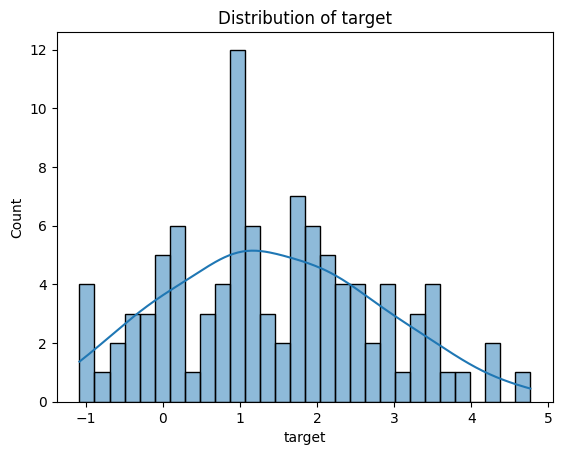

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.histplot(df["target"] , bins = 30 , kde = True)
plt.title("Distribution of target")
plt.show()

6.2

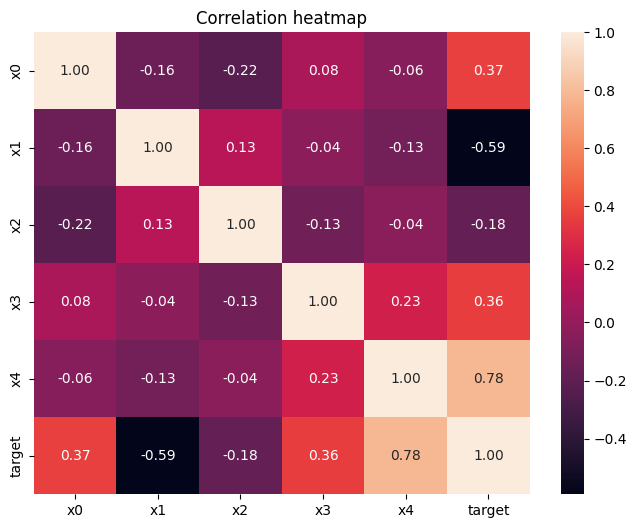

In [50]:
corr = df.corr(numeric_only = True)

plt.figure(figsize =(8,6))
sns.heatmap(corr,annot=True , fmt =".2f")
plt.title("Correlation heatmap")
plt.show()